In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Configuração visual de alto padrão
plt.style.use('dark_background')
sns.set_palette("husl")

In [2]:
print("1. Carregando a Base Corporativa...")
# Atualizado com o seu novo caminho
df = pd.read_parquet('../src/ifrs9_framework/data/raw/synthetic_credit_data.parquet')
print(f"Total de Contratos Analisados: {len(df)}")

1. Carregando a Base Corporativa...
Total de Contratos Analisados: 220359


In [3]:
df.head(10)

,cliente_id,idade,renda,uf,zona_risco_flag,bureau_score,obito_flag,codigo_contrato,tipo_produto,limite_credito,valor_financiado,selic_contratacao,default_flag
0,1,57.450712,8303.859373,PE,0,834.276107,0,95b06f8b,Cartão de Crédito,27266.335385,10630.588727,10.027129,0
1,2,47.926035,1444.785557,MG,0,585.865753,0,e6bc2234,Cartão de Crédito,2407.232315,946.772882,13.532248,0
2,2,47.926035,1444.785557,MG,0,585.865753,0,9ab3ee98,Crédito Pessoal,0.000000,7870.669957,10.088665,0
3,3,59.715328,5769.552223,SP,0,400.569660,0,f32d8416,Crédito Pessoal,0.000000,37910.336076,5.800350,0
4,4,72.845448,2218.550278,MG,1,391.704280,0,de19895b,Consignado SIAPE,0.000000,6751.607071,9.118638,0
5,5,46.487699,2801.969257,MA,0,548.602383,0,cb38a2bf,Cartão de Crédito,8188.272514,1315.828348,4.738383,0
6,5,46.487699,2801.969257,MA,0,548.602383,0,e78ce38a,Crédito Pessoal,0.000000,13443.308286,7.351543,0
7,6,46.487946,3782.284282,MA,0,362.922034,0,edc3684c,Consignado SIAPE,0.000000,10318.235376,13.742176,0
8,7,73.688192,3309.019360,MG,1,688.072210,0,ec4b42f5,Crédito Pessoal,0.000000,26018.407655,6.655614,0
9,7,73.688192,3309.019360,MG,1,688.072210,0,0207d53e,Crédito Pessoal,0.000000,28972.863585,5.809945,0


In [4]:
print("\n2. Engenharia do Espaço Vetorial (Pre-processing)...")
# Selecionamos features críticas para o cluster e transformamos strings em matriz binária
features_numericas = ['idade', 'renda', 'bureau_score', 'limite_credito', 'valor_financiado', 'selic_contratacao']
df_features = pd.get_dummies(df[features_numericas + ['tipo_produto']], columns=['tipo_produto'])


2. Engenharia do Espaço Vetorial (Pre-processing)...


In [5]:
# Padronização (Crucial para o PCA: média 0, variância 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

In [6]:
print("\n3. Redução de Dimensionalidade (PCA)...")
# Reduzindo dezenas de colunas para apenas 2 eixos principais (X e Y vetoriais)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]
print(f"Variância explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum()*100:.2f}%")


3. Redução de Dimensionalidade (PCA)...
Variância explicada pelos 2 componentes: 38.53%


In [7]:
print("\n4. Aplicando K-Means (Buscando 4 nichos de comportamento)...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df['cluster_id'] = kmeans.fit_predict(X_scaled)


4. Aplicando K-Means (Buscando 4 nichos de comportamento)...


/tmp/ipykernel_341/198681829.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=taxa_default_cluster.index, y=taxa_default_cluster.values, palette='viridis', ax=ax2)


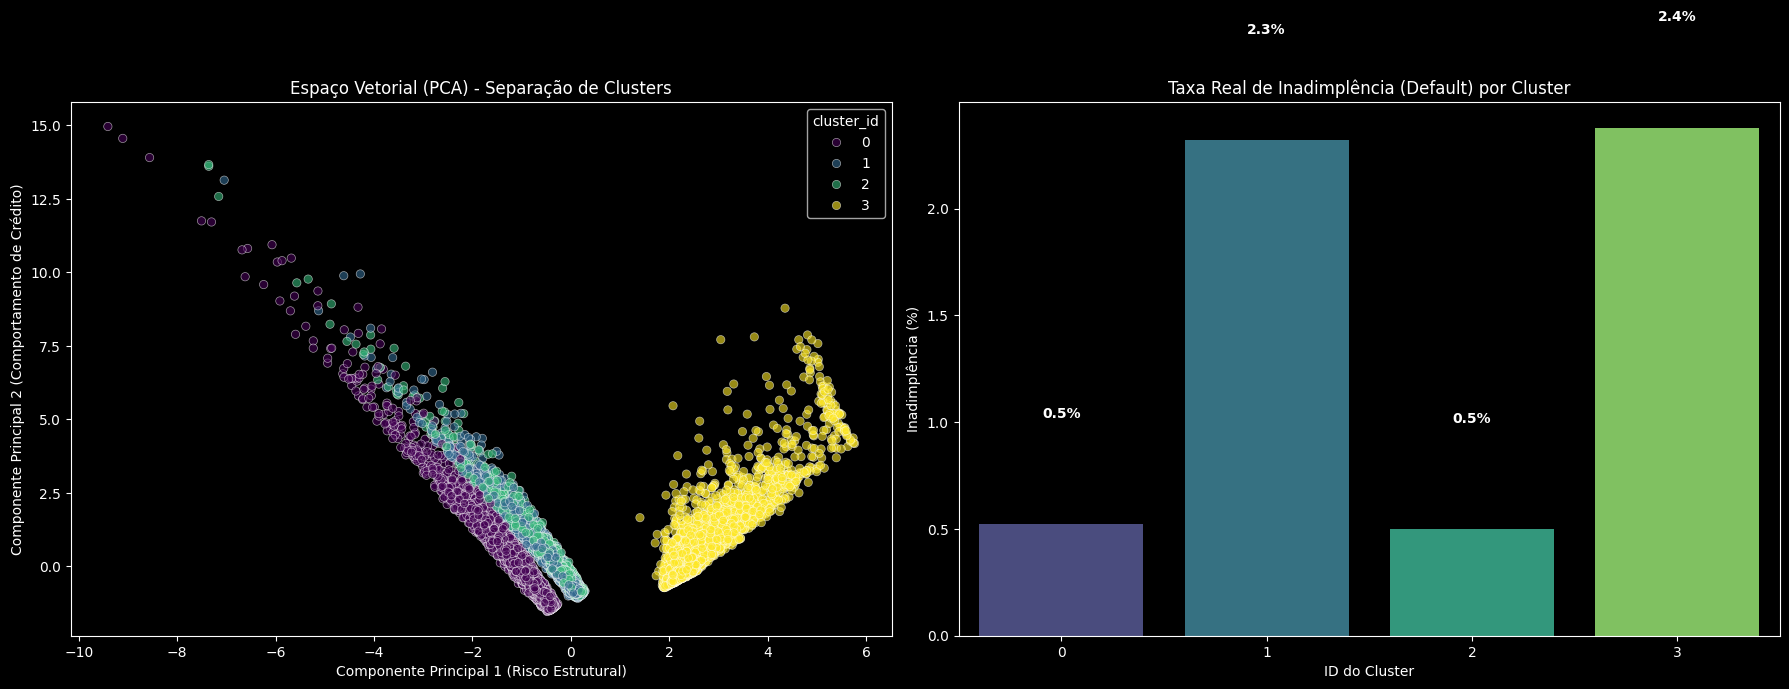


5. Perfil de Risco (A Resposta do Estudo):


,tipo_produto,bureau_score,renda,taxa_default
cluster_id,,,,
0,Consignado INSS,599.080078,5045.450338,0.5%
1,Crédito Pessoal,599.987442,4998.946242,2.3%
2,Consignado SIAPE,599.258607,5081.671255,0.5%
3,Cartão de Crédito,599.806051,5033.054933,2.4%


In [8]:
# ================= VIZUALIZAÇÃO =================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: A separação matemática dos clusters
sns.scatterplot(
    data=df.sample(20000), # Amostra para não travar a renderização gráfica
    x='pca_1', y='pca_2', 
    hue='cluster_id', 
    palette='viridis', 
    alpha=0.6, 
    ax=ax1
)
ax1.set_title("Espaço Vetorial (PCA) - Separação de Clusters")
ax1.set_xlabel("Componente Principal 1 (Risco Estrutural)")
ax1.set_ylabel("Componente Principal 2 (Comportamento de Crédito)")

# Gráfico 2: Prova de Fogo (Inadimplência por Cluster)
taxa_default_cluster = df.groupby('cluster_id')['default_flag'].mean() * 100
sns.barplot(x=taxa_default_cluster.index, y=taxa_default_cluster.values, palette='viridis', ax=ax2)
ax2.set_title("Taxa Real de Inadimplência (Default) por Cluster")
ax2.set_ylabel("Inadimplência (%)")
ax2.set_xlabel("ID do Cluster")

# Adicionando o rótulo de dados no gráfico de barras
for i, v in enumerate(taxa_default_cluster.values):
    ax2.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n5. Perfil de Risco (A Resposta do Estudo):")
# Descobrindo o que cada cluster representa no mundo real
perfil = df.groupby('cluster_id').agg({
    'tipo_produto': lambda x: x.value_counts().index[0], # Produto dominante no cluster
    'bureau_score': 'mean',
    'renda': 'mean',
    'default_flag': 'mean'
}).rename(columns={'default_flag': 'taxa_default'})
perfil['taxa_default'] = (perfil['taxa_default'] * 100).round(1).astype(str) + '%'

display(perfil)